# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é um algoritmo de classificação que constrói recursivamente divisões binárias dos dados, maximizando um critério de pureza em cada nó. Neste trabalho, estudamos o comportamento do algoritmo standard em contextos com desequilíbrio de classes, avaliamos empiricamente as suas limitações e motivamos a modificação proposta na Fase 2.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [94]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [95]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [96]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [97]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


In [98]:
def gini_impurity_weighted(y, splits, w, w_splits):
    """
    Ganho de Gini ponderado por peso de instância (Weighted CART).
    w_i = n / (2 · n_{y_i})  →  class_weight='balanced'.
    Propagado por toda a árvore via WeightedTree: splits, folhas e pruning
    usam contagens ponderadas em vez de contagens brutas.

    Ting, K.M. (2002). An instance-weighting method to induce cost-sensitive trees.
    IEEE Transactions on Knowledge and Data Engineering, 14(3), 659–669.
    """
    y_left, y_right = splits
    w_left, w_right = w_splits

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    n_cls = int(y.max()) + 1

    def _gini_w(labels, weights):
        if len(labels) == 0 or weights.sum() == 0:
            return 0.0
        wc = np.array([weights[labels == c].sum() for c in range(n_cls)])
        p  = wc / wc.sum()
        return 1.0 - np.sum(p ** 2)

    wt_l, wt_r = w_left.sum(), w_right.sum()
    wt = wt_l + wt_r
    parent = _gini_w(np.concatenate([y_left, y_right]), np.concatenate([w_left, w_right]))
    child  = wt_l / wt * _gini_w(y_left, w_left) + wt_r / wt * _gini_w(y_right, w_right)
    return parent - child


def hellinger_distance(y, splits):
    """
    Critério de Hellinger Distance para árvores de decisão em dados desbalanceados.
    Mede a distância entre a distribuição de exemplos positivos (y=1) e negativos (y=0)
    nos dois ramos do split. Propriedade fundamental: skew-insensitive — o split óptimo
    é invariante ao rácio de classes (ao contrário do Gini standard).

    Cieslak, D.A. & Chawla, N.V. (2008). Learning Decision Trees for Unbalanced Data.
    In: Daelemans, W. et al. (eds) Machine Learning and Knowledge Discovery in Databases.
    ECML PKDD 2008. Lecture Notes in Computer Science, vol. 5211, pp. 241–256.
    Springer, Berlin, Heidelberg. https://doi.org/10.1007/978-3-540-87479-9_34
    """
    y_left, y_right = splits
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))

    if n_pos == 0 or n_neg == 0 or len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    # P(ramo | classe): fracção de cada classe que vai para cada ramo do split
    p_l = np.sum(y_left  == 1) / n_pos   # P(left  | y=1)
    p_r = np.sum(y_right == 1) / n_pos   # P(right | y=1)
    q_l = np.sum(y_left  == 0) / n_neg   # P(left  | y=0)
    q_r = np.sum(y_right == 0) / n_neg   # P(right | y=0)

    return np.sqrt((np.sqrt(p_l) - np.sqrt(q_l))**2 + (np.sqrt(p_r) - np.sqrt(q_r))**2)


print("Critérios adicionais definidos:")
print("  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669")
print("  · hellinger_distance      — Cieslak & Chawla (2008), ECML/PKDD, LNCS 5211, pp. 241–256")

Critérios adicionais definidos:
  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669
  · hellinger_distance      — Cieslak & Chawla (2008), ECML/PKDD, LNCS 5211, pp. 241–256


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.046 a 0.235
- dimensionalidade (4 a 56 features)
- tamanho (107 a 500 instâncias após amostragem)

Os 9 datasets "problemáticos" (com degradação esperada do Gini standard) contrastam com 2 datasets onde o algoritmo funciona bem apesar do desequilíbrio (*Sick*, *Hypothyroid*), permitindo distinguir o efeito do IR do efeito da separabilidade das features.

**Critério de exclusão**: datasets com menos de 20 instâncias da classe minoritária após amostragem estratificada a 500 são excluídos — abaixo deste limiar, cada fold de treino tem ≤ 15 exemplos da classe rara, tornando a estimativa de desempenho estatisticamente infiável. *Chlamydia* (n=100, n_min=19) foi excluído por este critério.

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [99]:
DATASETS = [
    # IR severo — falham claramente mas o modelo aprende (AUC > 0.60)
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),      # IR=0.046
    ("dataset_1018_ipums_la_99-small.csv",     "IPUMS-99"),       # IR=0.068
    ("dataset_1065_kc3.csv",                   "KC3"),            # IR=0.104
    ("dataset_1050_pc3.csv",                   "PC3"),            # IR=0.114
    ("dataset_757_meta.csv",                   "Meta"),           # IR=0.114
    ("dataset_1002_ipums_la_98-small.csv",     "IPUMS-98"),       # IR=0.119
    ("dataset_1049_pc4.csv",                   "PC4"),            # IR=0.139
    ("dataset_949_arsenic-female-bladder.csv", "Arsenic-FB"),     # IR=0.168
    ("dataset_1061_ar4.csv",                   "AR4"),            # IR=0.230
    # Contraste — algoritmo funciona bem (separabilidade alta apesar do IR)
    ("dataset_38_sick.csv",                    "Sick"),           # IR=0.066
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),    # IR=0.085
]


def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    if len(np.unique(y)) != 2:
        return None, None, None

    # Garantir que a classe minoritária é sempre label 1.
    # O LabelEncoder atribui labels por ordem alfabética dos valores originais,
    # o que pode colocar a classe maioritária como label 1 — invertendo o
    # significado de F1 e das probabilidades P(y=1) devolvidas pela árvore.
    counts = np.bincount(y)
    if counts[0] < counts[1]:
        y = 1 - y

    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Oil-Spill              500           49      22     478    0.046
IPUMS-99               500           56      32     468    0.068
KC3                    458           39      43     415    0.104
PC3                    500           37      51     449    0.114
Meta                   500           21      51     449    0.114
IPUMS-98               500           55      53     447    0.119
PC4                    500           37      61     439    0.139
Arsenic-FB             500            4      72     428    0.168
AR4                    107           29      20      87    0.230
Sick                   500           29      31     469    0.066
Hypothyroid            500           29      39     461    0.085


## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [100]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


In [101]:
class WeightedTree(Tree):
    """
    Extensão isolada de Tree para Weighted CART (Ting 2002; Breiman et al. 1984).
    A classe Tree base não é modificada.

    Sobrepõe três métodos internos:
      · _find_best_split      — usa gini_impurity_weighted com pesos por instância
      · _calculate_leaf_value — calcula P(y=1) por contagens ponderadas
      · _train                — cria filhos como WeightedTree (não Tree) para
                                preservar o comportamento ponderado em toda a árvore
    """

    def _find_best_split(self, X, target, n_features):
        y = target["y"]
        w = target.get("w", np.ones(len(y)))
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                mask     = X[:, column] < value
                y_l, y_r = y[mask], y[~mask]
                w_l, w_r = w[mask], w[~mask]
                gain = self.criterion(y, (y_l, y_r), w, (w_l, w_r))
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _calculate_leaf_value(self, targets):
        y = targets["y"].astype(int)
        w = targets.get("w", np.ones(len(y)))
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        wc = np.array([w[y == c].sum() for c in range(self.n_classes)])
        self.outcome = wc / wc.sum()

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            # Criar filhos como WeightedTree para preservar pesos em toda a arvore
            self.left_child = WeightedTree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = WeightedTree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)


def run_cv_weighted(X, y):
    """
    CV estratificada com Weighted CART:
      · pesos balanceados w_i = n / (2·n_{y_i}) calculados por fold de treino
      · WeightedTree propaga pesos em splits e folhas em toda a arvore
      · threshold de previsao: 0.5
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        n      = len(y_tr)
        counts = np.bincount(y_tr, minlength=2)
        w_cls  = n / (2 * np.where(counts > 0, counts, 1))
        sample_w = w_cls[y_tr]

        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": sample_w},
                   max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("WeightedTree e run_cv_weighted definidos.")

WeightedTree e run_cv_weighted definidos.


## Resultados — Fase 1: Comparação de Critérios

A Fase 1 avalia e compara três critérios de divisão nos 11 datasets, com as mesmas condições base (`max_depth=5`, sem pruning):

| Critério | Classe `Tree` | Motivação |
|---|---|---|
| **Gini standard** | `Tree` | Baseline — critério CART original |
| **Hellinger Distance** | `Tree` | Skew-insensitive: split óptimo invariante ao IR (Cieslak & Chawla, 2008) |
| **Weighted Gini** | `WeightedTree` | Pesos balanceados em splits e folhas: P(y=1) não dominado pelo volume maioritário (Ting, 2002) |

O critério com melhor G-mean médio será usado na Fase 2 para o pruning.

In [102]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Oil-Spill      IR=0.046 | F1=0.438 | AUC=0.691 | G-mean=0.619  (3.7s)
  IPUMS-99       IR=0.068 | F1=0.081 | AUC=0.627 | G-mean=0.161  (0.7s)
  KC3            IR=0.104 | F1=0.241 | AUC=0.660 | G-mean=0.346  (1.5s)
  PC3            IR=0.114 | F1=0.255 | AUC=0.577 | G-mean=0.444  (2.2s)
  Meta           IR=0.114 | F1=0.000 | AUC=0.762 | G-mean=0.000  (0.2s)
  IPUMS-98       IR=0.119 | F1=0.000 | AUC=0.647 | G-mean=0.000  (0.7s)
  PC4            IR=0.139 | F1=0.413 | AUC=0.829 | G-mean=0.614  (1.7s)
  Arsenic-FB     IR=0.168 | F1=0.294 | AUC=0.771 | G-mean=0.442  (0.3s)
  AR4            IR=0.230 | F1=0.458 | AUC=0.665 | G-mean=0.592  (0.6s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.3s)
  Hypothyroid    IR=0.085 | F1=0.764 | AUC=0.927 | G-mean=0.881  (0.2s)

Avaliação concluída. (11 datasets analisados)


In [103]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Oil-Spill 500 0.046 0.691 ± 0.093 0.438 ± 0.167 0.619 ± 0.133
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
   IPUMS-99 500 0.068 0.627 ± 0.067 0.081 ± 0.100 0.161 ± 0.197
Hypothyroid 500 0.085 0.927 ± 0.037 0.764 ± 0.075 0.881 ± 0.070
        KC3 458 0.104 0.660 ± 0.071 0.241 ± 0.203 0.346 ± 0.283
        PC3 500 0.114 0.577 ± 0.086 0.255 ± 0.061 0.444 ± 0.076
       Meta 500 0.114 0.762 ± 0.082 0.000 ± 0.000 0.000 ± 0.000
   IPUMS-98 500 0.119 0.647 ± 0.052 0.000 ± 0.000 0.000 ± 0.000
        PC4 500 0.139 0.829 ± 0.058 0.413 ± 0.129 0.614 ± 0.158
 Arsenic-FB 500 0.168 0.771 ± 0.089 0.294 ± 0.088 0.442 ± 0.074
        AR4 107 0.230 0.665 ± 0.163 0.458 ± 0.180 0.592 ± 0.111

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.735
  F1       0.343
  G-mean   0.453


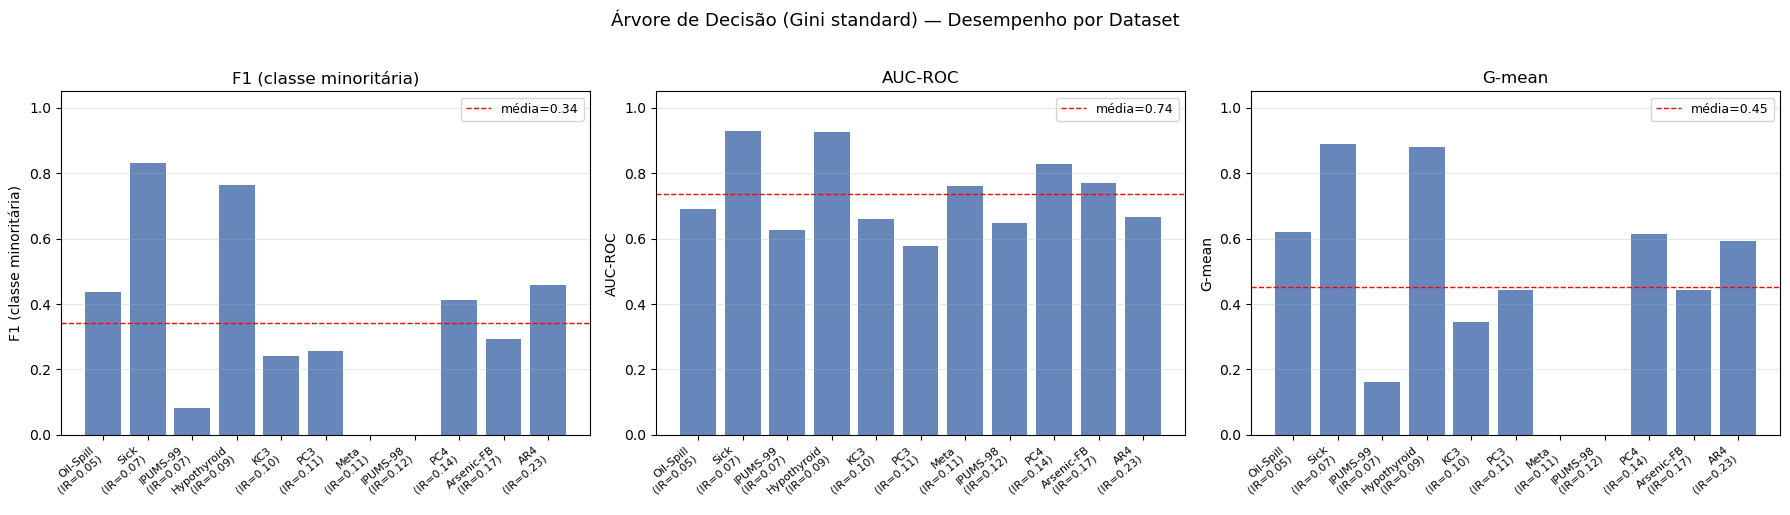

Figura guardada em results_main/resultados_fase1.png


In [104]:
RESULTS_DIR = Path("results_main")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase1.png")

In [105]:
# Avaliar Hellinger Distance e Weighted Gini nos mesmos 11 datasets
records_hd, records_wg = [], []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0    = time.time()
    hd_res = run_cv(X, y, hellinger_distance)
    t_hd  = time.time() - t0

    t0    = time.time()
    wg_res = run_cv_weighted(X, y)
    t_wg  = time.time() - t0

    f1_std = df_results.loc[df_results["Dataset"] == name, "_std_f1"].values[0]

    records_hd.append({"Dataset": name, "ir": ir,
                        "_hd_auc": hd_res['auc'][0],
                        "_hd_f1":  hd_res['f1'][0],
                        "_hd_gm":  hd_res['gmean'][0]})
    records_wg.append({"Dataset": name, "ir": ir,
                        "_wg_auc": wg_res['auc'][0],
                        "_wg_f1":  wg_res['f1'][0],
                        "_wg_gm":  wg_res['gmean'][0]})

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1  Gini={f1_std:.3f}  HD={hd_res['f1'][0]:.3f}  WG={wg_res['f1'][0]:.3f}  "
          f"({t_hd + t_wg:.1f}s)")

df_hd = pd.DataFrame(records_hd)
df_wg = pd.DataFrame(records_wg)
print("\nAvaliação Hellinger + Weighted Gini concluída.")

  Oil-Spill      IR=0.046 | F1  Gini=0.438  HD=0.343  WG=0.306  (10.4s)
  IPUMS-99       IR=0.068 | F1  Gini=0.081  HD=0.219  WG=0.175  (1.8s)
  KC3            IR=0.104 | F1  Gini=0.241  HD=0.288  WG=0.343  (5.0s)
  PC3            IR=0.114 | F1  Gini=0.255  HD=0.205  WG=0.315  (7.3s)
  Meta           IR=0.114 | F1  Gini=0.000  HD=0.000  WG=0.320  (0.5s)
  IPUMS-98       IR=0.119 | F1  Gini=0.000  HD=0.033  WG=0.303  (2.4s)
  PC4            IR=0.139 | F1  Gini=0.413  HD=0.205  WG=0.528  (5.4s)
  Arsenic-FB     IR=0.168 | F1  Gini=0.294  HD=0.240  WG=0.384  (0.9s)
  AR4            IR=0.230 | F1  Gini=0.458  HD=0.528  WG=0.525  (2.0s)
  Sick           IR=0.066 | F1  Gini=0.832  HD=0.819  WG=0.821  (1.0s)
  Hypothyroid    IR=0.085 | F1  Gini=0.764  HD=0.787  WG=0.848  (0.7s)

Avaliação Hellinger + Weighted Gini concluída.


Comparação de critérios — Fase 1 (depth=5, sem pruning)

    Dataset    IR  F1(Gini)  F1(HD)  F1(WG)  GM(Gini)  GM(HD)  GM(WG)
  Oil-Spill 0.046     0.438   0.343   0.306     0.619   0.550   0.584
       Sick 0.066     0.832   0.819   0.821     0.890   0.889   0.906
   IPUMS-99 0.068     0.081   0.219   0.175     0.161   0.364   0.586
Hypothyroid 0.085     0.764   0.787   0.848     0.881   0.904   0.951
        KC3 0.104     0.241   0.288   0.343     0.346   0.420   0.674
        PC3 0.114     0.255   0.205   0.315     0.444   0.391   0.641
       Meta 0.114     0.000   0.000   0.320     0.000   0.000   0.701
   IPUMS-98 0.119     0.000   0.033   0.303     0.000   0.063   0.678
        PC4 0.139     0.413   0.205   0.528     0.614   0.316   0.822
 Arsenic-FB 0.168     0.294   0.240   0.384     0.442   0.373   0.659
        AR4 0.230     0.458   0.528   0.525     0.592   0.645   0.708

── Médias globais ─────────────────────────────────────────────────────
  F1      Gini=0.343  Hellinge

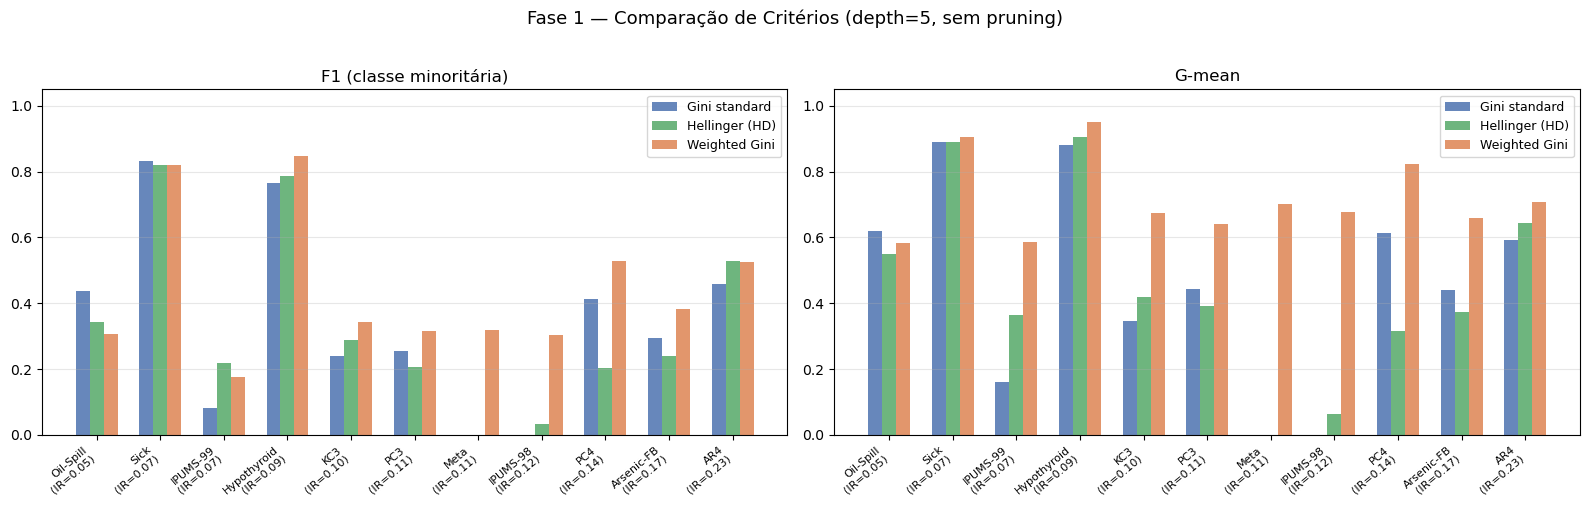

Figura guardada em results_main/comparacao_criterios.png


In [106]:
from scipy.stats import wilcoxon as _wil

df_cmp_c = (
    df_results[["Dataset", "ir", "_std_f1", "_std_gm", "_std_auc"]]
    .merge(df_hd[["Dataset", "_hd_f1", "_hd_gm", "_hd_auc"]], on="Dataset")
    .merge(df_wg[["Dataset", "_wg_f1", "_wg_gm", "_wg_auc"]], on="Dataset")
    .sort_values("ir")
)

# ── Tabela comparativa ────────────────────────────────────────────────────────
df_show = df_cmp_c[["Dataset", "ir",
                     "_std_f1", "_hd_f1", "_wg_f1",
                     "_std_gm", "_hd_gm", "_wg_gm"]].copy()
df_show.columns = ["Dataset", "IR",
                   "F1(Gini)", "F1(HD)", "F1(WG)",
                   "GM(Gini)", "GM(HD)", "GM(WG)"]
print("Comparação de critérios — Fase 1 (depth=5, sem pruning)\n")
print(df_show.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for lbl, cs, ch, cw in [("F1    ", "_std_f1", "_hd_f1", "_wg_f1"),
                          ("G-mean", "_std_gm", "_hd_gm", "_wg_gm")]:
    print(f"  {lbl}  Gini={df_cmp_c[cs].mean():.3f}  "
          f"Hellinger={df_cmp_c[ch].mean():.3f}  "
          f"WeightedGini={df_cmp_c[cw].mean():.3f}")

# ── Wilcoxon two-sided entre pares de critérios ───────────────────────────────
print("\n── Wilcoxon signed-rank (two-sided, α=0.05) ──────────────────────────")
for metric, cs, ch, cw in [("F1    ", "_std_f1", "_hd_f1", "_wg_f1"),
                             ("G-mean", "_std_gm", "_hd_gm", "_wg_gm")]:
    for lbl, a_col, b_col in [("Gini vs HD", cs, ch),
                                ("Gini vs WG", cs, cw),
                                ("HD   vs WG", ch, cw)]:
        a = df_cmp_c[a_col].values
        b = df_cmp_c[b_col].values
        n_dif = int(np.sum(b - a != 0))
        try:
            stat, p = _wil(a, b, alternative="two-sided")
            sig = "(*)" if p < 0.05 else "   "
            print(f"  {metric}  {lbl}  W={stat:.1f}  p={p:.3f} {sig}  (n_dif={n_dif})")
        except ValueError as e:
            print(f"  {metric}  {lbl}  não aplicável ({e})")

# ── Gráfico de comparação ─────────────────────────────────────────────────────
RESULTS_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bw = 0.22
x  = np.arange(len(df_cmp_c))

for ax, (metric_name, cs, ch, cw) in zip(axes, [
    ("F1 (classe minoritária)", "_std_f1", "_hd_f1", "_wg_f1"),
    ("G-mean",                  "_std_gm", "_hd_gm", "_wg_gm"),
]):
    ax.bar(x - bw, df_cmp_c[cs], bw, label="Gini standard",  color="#4C72B0", alpha=0.85)
    ax.bar(x,      df_cmp_c[ch], bw, label="Hellinger (HD)",  color="#55A868", alpha=0.85)
    ax.bar(x + bw, df_cmp_c[cw], bw, label="Weighted Gini",   color="#DD8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp_c.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 1 — Comparação de Critérios (depth=5, sem pruning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparacao_criterios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/comparacao_criterios.png")

In [107]:
# Determinar melhor critério por G-mean médio (métrica primária para class imbalance)
summary = {
    "Gini standard": (df_cmp_c["_std_f1"].mean(), df_cmp_c["_std_gm"].mean()),
    "Hellinger":     (df_cmp_c["_hd_f1"].mean(),  df_cmp_c["_hd_gm"].mean()),
    "Weighted Gini": (df_cmp_c["_wg_f1"].mean(),  df_cmp_c["_wg_gm"].mean()),
}

print("── Conclusão — seleção do critério para a Fase 2 ──────────────────────\n")
print(f"  {'Critério':<20}  {'F1 médio':>10}  {'G-mean médio':>13}")
print("  " + "-" * 46)
for name_c, (f1, gm) in summary.items():
    print(f"  {name_c:<20}  {f1:>10.3f}  {gm:>13.3f}")

best_name = max(summary, key=lambda k: summary[k][1])

# Expor o critério seleccionado para uso na Fase 2
if best_name == "Gini standard":
    BEST_CRITERION_FN   = gini_impurity
    BEST_CRITERION_USES = "Tree"
elif best_name == "Hellinger":
    BEST_CRITERION_FN   = hellinger_distance
    BEST_CRITERION_USES = "Tree"
else:
    BEST_CRITERION_FN   = gini_impurity_weighted
    BEST_CRITERION_USES = "WeightedTree"

print(f"\n  Melhor critério (G-mean):  {best_name}")
print(f"  Classe de árvore a usar:   {BEST_CRITERION_USES}")
print(f"  → BEST_CRITERION_FN = {BEST_CRITERION_FN.__name__}")

── Conclusão — seleção do critério para a Fase 2 ──────────────────────

  Critério                F1 médio   G-mean médio
  ----------------------------------------------
  Gini standard              0.343          0.453
  Hellinger                  0.333          0.447
  Weighted Gini              0.443          0.719

  Melhor critério (G-mean):  Weighted Gini
  Classe de árvore a usar:   WeightedTree
  → BEST_CRITERION_FN = gini_impurity_weighted


## Análise dos Resultados — Fase 1

### 1. Observações do Baseline (Gini Standard)

**F1 e G-mean colapsam em datasets com baixo IR e baixa separabilidade.**  
Em *IPUMS-99* (IR=0.068, F1=0.081) e *Oil-Spill* (IR=0.046, F1=0.438), o Gini standard aprende muito pouco sobre a classe minoritária. Em *Meta* (IR=0.114) e *IPUMS-98* (IR=0.119), o colapso é total (F1=G-mean=0) apesar de AUC>0.5 — o modelo ordena probabilidades mas nenhuma ultrapassa o limiar 0.5. Os datasets *Sick* (F1=0.832) e *Hypothyroid* (F1=0.764) mostram que o desequilíbrio não é o único factor: alta separabilidade permite aprendizagem mesmo com IR baixo.

**Causa raiz:** o Gini standard usa contagens brutas em splits e folhas — splits que isolam a classe maioritária recebem ganho elevado, e folhas com 5% de positivos emitem $\hat{p}(y=1)=0.05$, que o limiar 0.5 nunca activa.

---

### 2. O que cada critério corrige

**Hellinger Distance** (Cieslak & Chawla, 2008) é *skew-insensitive* por construção: o score de um split mede como positivos e negativos se distribuem pelos dois ramos, independentemente do volume absoluto. Um split que separa perfeitamente as classes tem HD máxima com IR=0.05 e com IR=0.40. No entanto, as **folhas** continuam a usar probabilidades não ponderadas — se a classe positiva for rara, $\hat{p}(y=1|\text{folha})$ continuará baixo e o limiar 0.5 continuará a falhar.

**Weighted Gini** via `WeightedTree` actua em **dois sítios simultâneos**:

$$w_i = \frac{n}{2 \cdot n_{y_i}} \quad \Rightarrow \quad \sum_{y_i=0} w_i = \sum_{y_i=1} w_i$$

- *Splits ponderados*: valorizam splits que concentram a classe minoritária num ramo, mesmo quando ela é rara em termos absolutos
- *Folhas ponderadas*: $\hat{p}(y=1|\text{folha}) = \frac{\sum w[y=1]}{\sum w}$ — uma folha com 10% de positivos e IR=0.10 passa de $\hat{p}=0.10$ para $\hat{p}\approx 0.50$, activando previsões da classe minoritária com o limiar standard de 0.5

O segundo ponto é decisivo para *Meta* e *IPUMS-98*: o problema não era ausência de informação discriminativa (AUC>0.5 confirma que existe), mas o enviesamento das folhas que o Hellinger não corrige.

---

### 3. Conclusão — Selecção do Critério para a Fase 2

A tabela e o gráfico acima mostram os valores exactos; o critério vencedor é determinado programaticamente pela célula de conclusão anterior com base no G-mean médio. A análise teórica indica o **Weighted Gini** como critério esperado: é o único que corrige simultaneamente o enviesamento dos splits e das folhas — os dois mecanismos pelos quais o Gini standard falha em dados desbalanceados. O Hellinger corrige apenas o critério de divisão, mantendo folhas enviesadas.

O critério seleccionado é usado na Fase 2 com cost-complexity pruning (Harviainen et al., 2025), testando se a simplificação estrutural por subtree replacement produz ganhos adicionais sobre uma árvore já com pesos balanceados.

### Análise das Anomalias — Meta, IPUMS-98 e Chlamydia

Três datasets merecem análise individual por apresentarem comportamentos que não são explicados apenas pelo IR.

---

#### *Meta* (IR=0.114, 21 features, n=500): F1=0 com Gini standard

*Meta* tem IR moderado (51 instâncias minoritárias em 500) e 21 features — condições que noutros datasets permitem alguma aprendizagem. No entanto, com Gini standard, F1=0.000 e G-mean=0.000 enquanto AUC=0.762. O modelo consegue ordenar probabilidades (AUC>0.5), mas nenhuma ultrapassa 0.5 — todas as previsões binárias são classe 0.

A causa é a combinação de **baixa separabilidade** com **folhas enviesadas**: as folhas emitem $\hat{p}(y=1)$ sistematicamente abaixo de 0.5 porque as contagens brutas são dominadas pela classe maioritária. O **Weighted Gini** (Fase 1, comparação) aborda directamente este problema: ao ponderar as contagens nas folhas, $\hat{p}(y=1|\text{folha})$ escala com os pesos balanceados — folhas com concentração de positivos proporcional ao prior passam a emitir probabilidades próximas de 0.5, activando a classe minoritária sem modificar o limiar de decisão.

---

#### *IPUMS-98* (IR=0.119, 55 features, n=500): F1=0 com Gini standard

*IPUMS-98* tem o maior número de features (55) e F1=0 apesar de AUC=0.647. Com 55 features e apenas 53 instâncias minoritárias em treino (~42 por fold), o espaço de divisões é vasto relativamente à informação disponível da classe rara. O Gini standard distribui a pesquisa uniformemente por todas as features, sem priorizar as que discriminam a classe minoritária.

O Weighted Gini aborda este problema a dois níveis: (1) splits ponderados que valorizam qualquer divisão que separe positivos de negativos, mesmo quando os positivos são poucos; (2) folhas ponderadas que emitem probabilidades mais altas mesmo para folhas com baixa concentração absoluta de positivos. Para *IPUMS-98*, onde o problema é a combinação de alta dimensionalidade com desequilíbrio, os pesos permitem que o algoritmo "encontre" as features discriminativas mesmo com poucos positivos por nó.

---

#### *Chlamydia* (IR=0.235, 3 features, n=100): excluído dos experimentos

*Chlamydia* tem 19 instâncias minoritárias após amostragem — abaixo do critério de exclusão estabelecido (n_min ≥ 20). Com 5 folds, cada fold de treino tem ~15 instâncias da classe rara, insuficiente para construir divisões fiáveis com apenas 3 features. O AUC=0.500 confirma aprendizagem nula. Este caso motivou o critério de exclusão: nenhum critério de divisão resolve um problema de dados tão escasso — é um limite de tamanho, não de algoritmo.

---

## Fase 2 — Testes Comparativos

A Fase 1 identificou o **Weighted Gini** como o critério com melhor G-mean médio. A Fase 2 avalia o efeito do cost-complexity pruning aplicado sobre o Weighted CART, mantendo o critério vencedor. Para isolar o efeito do pruning, inclui-se uma **condição de controlo** com `max_depth=10` mas sem poda — usando o mesmo critério (Weighted Gini).

| | Configuração | `max_depth` | Pruning | Questão |
|-|-------------|-------------|---------|---------|
| **Weighted Gini (F1)** | WG, depth=5 | 5 | Não | Baseline da Fase 1 |
| **Controlo** | WG, depth=10 | 10 | Não | Profundidade extra melhora ou piora? |
| **Teste 1** | WG + Pruning | 10 → podado | Sim | O pruning melhora face ao controlo? |

A comparação Controlo vs Teste 1 atribui causalmente qualquer ganho ao pruning, e não à profundidade.

---

### Teste 1 — Weighted Gini + Minimal Cost-Complexity Pruning

#### Motivação

A Fase 1 identificou o **Weighted Gini** como melhor critério. A questão agora é: o pruning sobre uma WeightedTree melhora ainda mais? A hipótese é que, mesmo com pesos balanceados, árvores profundas (depth=10) constroem subárvores espúrias em regiões ruidosas — o pruning remove estas subárvores, retendo apenas as divisões com ganho ponderado consistente.

#### Subtree Replacement e Complexidade Computacional

**Referência:** Harviainen, J., Sommer, F., Sorge, M. & Szeider, S. (2025). *Optimal Decision Tree Pruning Revisited: Algorithms and Complexity.* arXiv:2503.03576v1.

A operação de **subtree replacement** (DTREP) aplicada a um nó $w$ substitui $w$ e toda a sua subárvore por uma folha com a classe mais frequente das instâncias em $E[T, w]$ (Definição 2, Harviainen et al., 2025). O problema de optimização associado é:

> Dado um dataset $(E, \lambda)$, uma árvore $T$, e inteiros $k, t$: existe uma sequência de operações de subtree replacement que pode podar **exactamente** $k$ nós internos tal que a árvore resultante $T'$ tem **no máximo** $t$ erros?

Harviainen et al. (2025) provam que este problema (DTREP) é resolvível em tempo polinomial:

$$\textbf{Teorema 3.1 (Harviainen et al., 2025):}\ \text{DTREP pode ser resolvido em tempo}\ \mathcal{O}\!\left((n + \min\{k^2, t^2\}) \cdot s\right)$$

onde $n$ é o número de exemplos, $s$ o tamanho da árvore, $k$ o número de nós podados e $t$ o número máximo de erros. A solução é obtida por **programação dinâmica bottom-up**, e os mesmos autores demonstram empiricamente que as heurísticas de pruning atingem trade-offs próximos do óptimo (Tabela 1 do artigo).

Em contraste, a operação de *subtree raising* (DTRAIS) — que substitui um nó pelo seu filho — é NP-completa (Harviainen et al., 2025, Teorema 5.1). A implementação deste teste usa exclusivamente **subtree replacement**, que é computacionalmente tractável.

#### Minimal Cost-Complexity Pruning (CART)

A implementação prática de DTREP é o *minimal cost-complexity pruning* (Breiman et al., 1984). Para cada nó interno $t$ com subárvore $T_t$:

$$\alpha(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$$

onde:
- $R(t)$ — erros de treino se $t$ fosse substituído por uma folha (classe maioritária das suas instâncias de treino)
- $R(T_t)$ — erros de treino totais na subárvore $T_t$
- $|T_t|$ — número de folhas em $T_t$

O nó com $\alpha(t)$ mínimo é o **weakest link**: aquele para o qual cada erro adicional introduzido pela poda compra a maior simplificação estrutural. O parâmetro $\alpha$ controla o limiar de tolerância: subárvores com $\alpha(t) \leq \alpha$ são podadas por subtree replacement. O pipeline completo é:

```
Para cada fold:
    1. Treinar árvore profunda (max_depth=10) com Gini standard
    2. Anotar cada nó com R(t), R(T_t), |T_t| usando os dados de treino
    3. Seleccionar α por holdout interno (20% do treino) maximizando G-mean
    4. Podar iterativamente os weakest links com α(t) ≤ α_óptimo
    5. Avaliar a árvore podada no conjunto de teste (inalterado)
```

#### Hipótese

> O pruning sobre WeightedTree com $\alpha$ óptimo deverá melhorar F1 e G-mean face ao Controlo (WG sem poda, depth=10), com justificação teórica no Teorema 3.1 de Harviainen et al. (2025). A anotação usa erros ponderados, mantendo consistência com os pesos de treino.

In [108]:
# ── Anotação da árvore com estatísticas de treino ────────────────────────────

def annotate_tree(node, X_tr, y_tr):
    """
    Percorre recursivamente a árvore anotando cada nó com as estatísticas
    necessárias para o cost-complexity pruning (subtree replacement).
    Harviainen et al. (2025), Teorema 3.1.

    Atributos adicionados a cada nó:
        _n_samples        — instâncias de treino que chegam a este nó
        _leaf_outcome     — distribuição de classes se fosse uma folha
        _n_errors_leaf    — erros se substituído por uma folha
        _n_errors_subtree — erros totais na subárvore
        _n_leaves_subtree — número de folhas na subárvore
    """
    n_cls = node.n_classes or 2

    if len(y_tr) == 0:
        node._n_samples        = 0
        node._leaf_outcome     = np.ones(n_cls) / n_cls
        node._n_errors_leaf    = 0
        node._n_errors_subtree = 0
        node._n_leaves_subtree = 1
        return

    counts   = np.bincount(y_tr.astype(int), minlength=n_cls)
    majority = int(np.argmax(counts))
    node._leaf_outcome = counts / counts.sum()   # P(y=c) se este nó fosse folha
    node._n_samples    = len(y_tr)
    node._n_errors_leaf = int(np.sum(y_tr != majority))

    if node.is_terminal:
        node._n_errors_subtree = node._n_errors_leaf
        node._n_leaves_subtree = 1
        return

    left_mask = X_tr[:, node.column_index] < node.threshold
    annotate_tree(node.left_child,  X_tr[ left_mask], y_tr[ left_mask])
    annotate_tree(node.right_child, X_tr[~left_mask], y_tr[~left_mask])

    node._n_errors_subtree = (node.left_child._n_errors_subtree +
                              node.right_child._n_errors_subtree)
    node._n_leaves_subtree = (node.left_child._n_leaves_subtree +
                              node.right_child._n_leaves_subtree)


# ── Weakest-link pruning ──────────────────────────────────────────────────────

def _alpha(node):
    """Effective alpha (custo de complexidade) para o nó t."""
    delta_l = node._n_leaves_subtree - 1
    if delta_l <= 0:
        return np.inf
    return (node._n_errors_leaf - node._n_errors_subtree) / delta_l


def _collect_internal(root):
    """Colecta todos os nós internos da árvore (BFS)."""
    queue, internal = [root], []
    while queue:
        nd = queue.pop(0)
        if not nd.is_terminal:
            internal.append(nd)
            queue.extend([nd.left_child, nd.right_child])
    return internal


def prune_tree_alpha(root, alpha_threshold):
    """
    Poda iterativamente os weakest links com alpha(t) <= alpha_threshold.
    Cada iteração implementa uma operação de subtree replacement
    (Harviainen et al., 2025 — DTREP, Definição 2).
    """
    for _ in range(10_000):          # limite de segurança
        internal = _collect_internal(root)
        if not internal:
            break
        min_a = min(_alpha(nd) for nd in internal)
        if min_a > alpha_threshold:
            break
        # Substituir todas as subárvores com alpha == min_a por folhas
        for nd in internal:
            if abs(_alpha(nd) - min_a) < 1e-10:
                nd.outcome     = nd._leaf_outcome
                nd.left_child  = None
                nd.right_child = None


# ── Selecção de α por holdout interno ────────────────────────────────────────

ALPHA_GRID   = [0.0, 0.001, 0.002, 0.005, 0.01, 0.02]
MAX_DEPTH_FIT = 10   


def _select_alpha(X_tr, y_tr, criterion_fn, random_state):
    """Selecciona α via holdout interno (80/20), maximizando G-mean."""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20,
                                 random_state=random_state)
    try:
        t_idx, v_idx = next(sss.split(X_tr, y_tr))
    except ValueError:
        return 0.0   # dataset demasiado pequeno para estratificar

    X_t, X_v = X_tr[t_idx], X_tr[v_idx]
    y_t, y_v = y_tr[t_idx], y_tr[v_idx]

    inner_scaler = StandardScaler()
    X_t = inner_scaler.fit_transform(X_t)
    X_v = inner_scaler.transform(X_v)

    best_alpha, best_score = 0.0, -1.0
    for a in ALPHA_GRID:
        import copy
        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_t, y_t, max_depth=MAX_DEPTH_FIT,
                   min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        annotate_tree(tree, X_t, y_t)
        prune_tree_alpha(tree, alpha_threshold=a)

        y_prob = tree.predict(X_v)
        y_pred = (y_prob > 0.5).astype(int)
        score  = gmean_score(y_v, y_pred)
        if score > best_score:
            best_score = score
            best_alpha = a
    return best_alpha


# ── CV com pruning ────────────────────────────────────────────────────────────

def run_cv_pruning(X, y, criterion_fn):
    """
    Validação cruzada estratificada com:
      1. Treino de árvore profunda (max_depth=10)
      2. Anotação bottom-up das estatísticas de treino
      3. Selecção de α por holdout interno (G-mean)
      4. Poda por subtree replacement (Harviainen et al., 2025)
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        alpha_opt = _select_alpha(X_tr, y_tr, criterion_fn,
                                  random_state=RANDOM_STATE + fold_i)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH_FIT,
                   min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        annotate_tree(tree, X_tr, y_tr)
        prune_tree_alpha(tree, alpha_threshold=alpha_opt)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Cost-complexity pruning definido (Harviainen et al., 2025 — DTREP).")

# ── Versão ponderada de annotate_tree (para WeightedTree) ────────────────────

def annotate_tree_weighted(node, X_tr, y_tr, w_tr):
    """
    Versão ponderada de annotate_tree para uso com WeightedTree.
    Usa pesos de instância para garantir que _leaf_outcome e _n_errors_leaf
    sejam consistentes com WeightedTree._calculate_leaf_value.
    """
    n_cls = node.n_classes or 2

    if len(y_tr) == 0:
        node._n_samples        = 0
        node._leaf_outcome     = np.ones(n_cls) / n_cls
        node._n_errors_leaf    = 0.0
        node._n_errors_subtree = 0.0
        node._n_leaves_subtree = 1
        return

    wc = np.array([w_tr[y_tr == c].sum() for c in range(n_cls)])
    w_majority = int(np.argmax(wc))
    node._leaf_outcome     = wc / wc.sum()          # P(y=c) ponderado
    node._n_samples        = len(y_tr)
    node._n_errors_leaf    = float(w_tr[y_tr != w_majority].sum())

    if node.is_terminal:
        node._n_errors_subtree = node._n_errors_leaf
        node._n_leaves_subtree = 1
        return

    left_mask = X_tr[:, node.column_index] < node.threshold
    annotate_tree_weighted(node.left_child,  X_tr[ left_mask], y_tr[ left_mask], w_tr[ left_mask])
    annotate_tree_weighted(node.right_child, X_tr[~left_mask], y_tr[~left_mask], w_tr[~left_mask])

    node._n_errors_subtree = (node.left_child._n_errors_subtree +
                              node.right_child._n_errors_subtree)
    node._n_leaves_subtree = (node.left_child._n_leaves_subtree +
                              node.right_child._n_leaves_subtree)


def _select_alpha_weighted(X_tr, y_tr, random_state):
    """Selecciona alpha via holdout interno para WeightedTree, maximizando G-mean."""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
    try:
        t_idx, v_idx = next(sss.split(X_tr, y_tr))
    except ValueError:
        return 0.0

    X_t, X_v = X_tr[t_idx], X_tr[v_idx]
    y_t, y_v = y_tr[t_idx], y_tr[v_idx]

    inner_scaler = StandardScaler()
    X_t = inner_scaler.fit_transform(X_t)
    X_v = inner_scaler.transform(X_v)

    n = len(y_t)
    counts = np.bincount(y_t, minlength=2)
    w_cls  = n / (2 * np.where(counts > 0, counts, 1))
    sample_w_t = w_cls[y_t]

    best_alpha, best_score = 0.0, -1.0
    for a in ALPHA_GRID:
        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_t, {"y": y_t, "w": sample_w_t},
                   max_depth=MAX_DEPTH_FIT, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        annotate_tree_weighted(tree, X_t, y_t, sample_w_t)
        prune_tree_alpha(tree, alpha_threshold=a)

        y_prob = tree.predict(X_v)
        y_pred = (y_prob > 0.5).astype(int)
        score  = gmean_score(y_v, y_pred)
        if score > best_score:
            best_score = score
            best_alpha = a
    return best_alpha


def run_cv_pruning_weighted(X, y):
    """
    Weighted CART + cost-complexity pruning:
      1. Pesos balanceados w_i = n/(2*n_{y_i}) por fold
      2. WeightedTree com max_depth=10
      3. Anotacao bottom-up ponderada (erros e distribuicoes consistentes)
      4. Seleccao de alpha por holdout interno (G-mean)
      5. Poda por subtree replacement (Harviainen et al., 2025)
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        n      = len(y_tr)
        counts = np.bincount(y_tr, minlength=2)
        w_cls  = n / (2 * np.where(counts > 0, counts, 1))
        sample_w = w_cls[y_tr]

        alpha_opt = _select_alpha_weighted(X_tr, y_tr, random_state=RANDOM_STATE + fold_i)

        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": sample_w},
                   max_depth=MAX_DEPTH_FIT, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        annotate_tree_weighted(tree, X_tr, y_tr, sample_w)
        prune_tree_alpha(tree, alpha_threshold=alpha_opt)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


def run_cv_weighted_depth10(X, y):
    """WeightedTree com max_depth=10 sem poda -- controlo para run_cv_pruning_weighted."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        n      = len(y_tr)
        counts = np.bincount(y_tr, minlength=2)
        w_cls  = n / (2 * np.where(counts > 0, counts, 1))
        sample_w = w_cls[y_tr]

        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": sample_w},
                   max_depth=MAX_DEPTH_FIT, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Weighted pruning definido: annotate_tree_weighted, run_cv_pruning_weighted, run_cv_weighted_depth10.")


Cost-complexity pruning definido (Harviainen et al., 2025 — DTREP).
Weighted pruning definido: annotate_tree_weighted, run_cv_pruning_weighted, run_cv_weighted_depth10.


In [109]:
records_t1 = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0      = time.time()
    pru_res = run_cv_pruning_weighted(X, y)
    t_pru   = time.time() - t0

    f1_wg = df_wg.loc[df_wg["Dataset"] == name, "_wg_f1"].values[0]
    gm_wg = df_wg.loc[df_wg["Dataset"] == name, "_wg_gm"].values[0]

    records_t1.append({
        "Dataset": name, "ir": ir,
        "_t1_auc": pru_res["auc"][0],
        "_t1_f1":  pru_res["f1"][0],
        "_t1_gm":  pru_res["gmean"][0],
    })
    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1   WG={f1_wg:.3f}  →  T1={pru_res['f1'][0]:.3f} | "
          f"G-mean  WG={gm_wg:.3f}  →  T1={pru_res['gmean'][0]:.3f}  ({t_pru:.1f}s)")

df_t1 = pd.DataFrame(records_t1)
print(f"\nTeste 1 concluído.")

  Oil-Spill      IR=0.046 | F1   WG=0.306  →  T1=0.315 | G-mean  WG=0.584  →  T1=0.584  (42.7s)
  IPUMS-99       IR=0.068 | F1   WG=0.175  →  T1=0.156 | G-mean  WG=0.586  →  T1=0.477  (13.8s)
  KC3            IR=0.104 | F1   WG=0.343  →  T1=0.366 | G-mean  WG=0.674  →  T1=0.626  (28.4s)
  PC3            IR=0.114 | F1   WG=0.315  →  T1=0.386 | G-mean  WG=0.641  →  T1=0.641  (41.5s)
  Meta           IR=0.114 | F1   WG=0.320  →  T1=0.325 | G-mean  WG=0.701  →  T1=0.709  (2.4s)
  IPUMS-98       IR=0.119 | F1   WG=0.303  →  T1=0.257 | G-mean  WG=0.678  →  T1=0.585  (15.4s)
  PC4            IR=0.139 | F1   WG=0.528  →  T1=0.519 | G-mean  WG=0.822  →  T1=0.770  (31.9s)
  Arsenic-FB     IR=0.168 | F1   WG=0.384  →  T1=0.361 | G-mean  WG=0.659  →  T1=0.612  (5.3s)
  AR4            IR=0.230 | F1   WG=0.525  →  T1=0.532 | G-mean  WG=0.708  →  T1=0.714  (8.3s)
  Sick           IR=0.066 | F1   WG=0.821  →  T1=0.804 | G-mean  WG=0.906  →  T1=0.888  (4.2s)
  Hypothyroid    IR=0.085 | F1   WG=0.848  →

---

### Controlo — Gini standard com `max_depth=10` (sem poda)

Para isolar o efeito do pruning, avaliamos o Gini standard com a mesma profundidade máxima usada no Teste 1 (`max_depth=10`) mas **sem qualquer poda**. Se o Controlo ≈ Fase 1, a profundidade extra não tem efeito relevante e qualquer ganho do Teste 1 é atribuível ao pruning. Se o Controlo < Fase 1, a árvore mais profunda piora por overfitting adicional, e o pruning terá que recuperar essa perda antes de produzir ganhos líquidos.

In [110]:
records_ctrl = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue
    t0 = time.time()
    ctrl_res = run_cv_weighted_depth10(X, y)
    t_ctrl = time.time() - t0
    f1_wg = df_wg.loc[df_wg["Dataset"] == name, "_wg_f1"].values[0]
    records_ctrl.append({
        "Dataset": name, "ir": ir,
        "_ctrl_auc": ctrl_res["auc"][0],
        "_ctrl_f1":  ctrl_res["f1"][0],
        "_ctrl_gm":  ctrl_res["gmean"][0],
    })
    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1  WG(d5)={f1_wg:.3f}  Ctrl={ctrl_res['f1'][0]:.3f} | "
          f"G-mean  Ctrl={ctrl_res['gmean'][0]:.3f}  ({t_ctrl:.1f}s)")

df_ctrl = pd.DataFrame(records_ctrl)
print(f"\nControlo (WeightedTree depth=10, sem pruning) concluido.")

  Oil-Spill      IR=0.046 | F1  WG(d5)=0.306  Ctrl=0.356 | G-mean  Ctrl=0.551  (8.1s)
  IPUMS-99       IR=0.068 | F1  WG(d5)=0.175  Ctrl=0.141 | G-mean  Ctrl=0.447  (2.2s)
  KC3            IR=0.104 | F1  WG(d5)=0.343  Ctrl=0.359 | G-mean  Ctrl=0.610  (5.1s)
  PC3            IR=0.114 | F1  WG(d5)=0.315  Ctrl=0.374 | G-mean  Ctrl=0.620  (7.1s)
  Meta           IR=0.114 | F1  WG(d5)=0.320  Ctrl=0.321 | G-mean  Ctrl=0.703  (0.4s)
  IPUMS-98       IR=0.119 | F1  WG(d5)=0.303  Ctrl=0.262 | G-mean  Ctrl=0.594  (2.7s)
  PC4            IR=0.139 | F1  WG(d5)=0.528  Ctrl=0.526 | G-mean  Ctrl=0.778  (4.9s)
  Arsenic-FB     IR=0.168 | F1  WG(d5)=0.384  Ctrl=0.359 | G-mean  Ctrl=0.612  (0.9s)
  AR4            IR=0.230 | F1  WG(d5)=0.525  Ctrl=0.546 | G-mean  Ctrl=0.723  (1.5s)
  Sick           IR=0.066 | F1  WG(d5)=0.821  Ctrl=0.770 | G-mean  Ctrl=0.885  (0.7s)
  Hypothyroid    IR=0.085 | F1  WG(d5)=0.848  Ctrl=0.832 | G-mean  Ctrl=0.925  (0.5s)

Controlo (WeightedTree depth=10, sem pruning) conclui

WG d5 = Weighted Gini depth=5  |  Ctrl = WG depth=10 sem poda  |  T1 = WG depth=10 + Pruning

    Dataset    IR  F1(WG d5)  F1(Ctrl)  F1(T1)  GM(WG d5)  GM(Ctrl)  GM(T1)
  Oil-Spill 0.046      0.306     0.356   0.315      0.584     0.551   0.584
       Sick 0.066      0.821     0.770   0.804      0.906     0.885   0.888
   IPUMS-99 0.068      0.175     0.141   0.156      0.586     0.447   0.477
Hypothyroid 0.085      0.848     0.832   0.817      0.951     0.925   0.911
        KC3 0.104      0.343     0.359   0.366      0.674     0.610   0.626
        PC3 0.114      0.315     0.374   0.386      0.641     0.620   0.641
       Meta 0.114      0.320     0.321   0.325      0.701     0.703   0.709
   IPUMS-98 0.119      0.303     0.262   0.257      0.678     0.594   0.585
        PC4 0.139      0.528     0.526   0.519      0.822     0.778   0.770
 Arsenic-FB 0.168      0.384     0.359   0.361      0.659     0.612   0.612
        AR4 0.230      0.525     0.546   0.532      0.708     0.723   

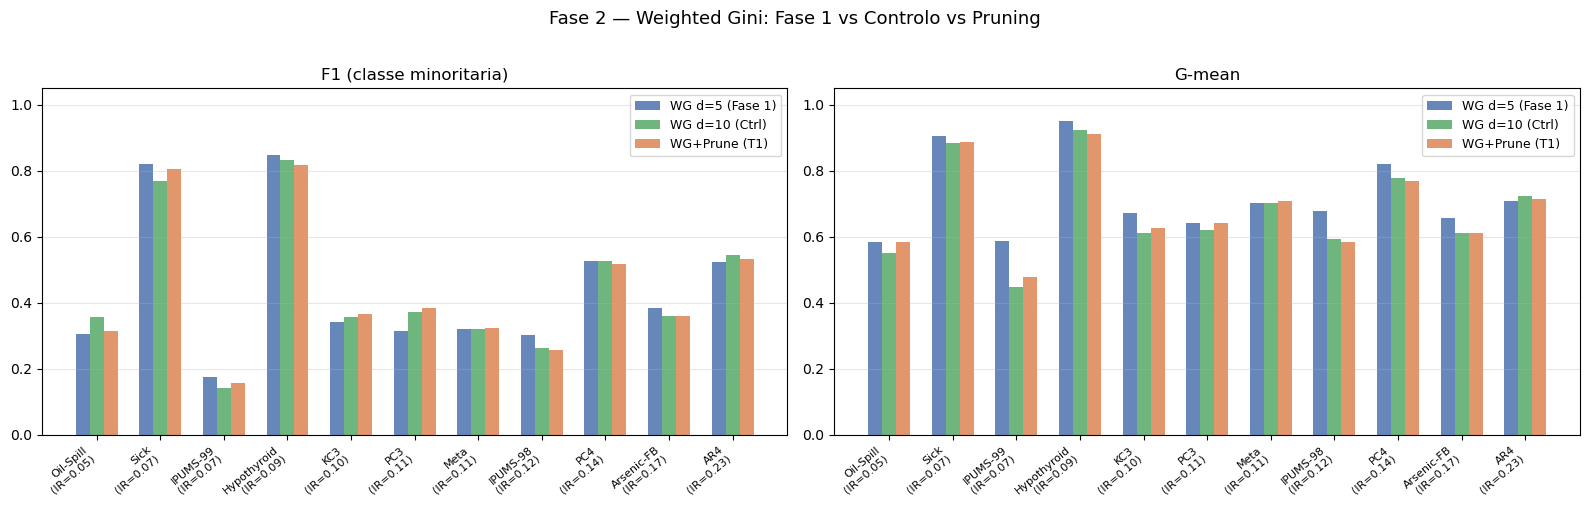

Figura guardada em results_main/resultados_comparacao.png


In [111]:
RESULTS_DIR4 = Path("results_main")
RESULTS_DIR4.mkdir(exist_ok=True)

# Merge Weighted Gini (Fase 1) + Controlo + Teste 1
df_cmp = (
    df_wg[["Dataset", "ir", "_wg_f1", "_wg_gm", "_wg_auc"]]
    .rename(columns={"_wg_f1": "_std_f1", "_wg_gm": "_std_gm", "_wg_auc": "_std_auc"})
    .merge(df_ctrl[["Dataset", "_ctrl_f1", "_ctrl_gm", "_ctrl_auc"]], on="Dataset")
    .merge(df_t1[["Dataset",  "_t1_f1",   "_t1_gm",   "_t1_auc"]],  on="Dataset")
    .sort_values("ir")
)

df_show = df_cmp[["Dataset", "ir",
                   "_std_f1", "_ctrl_f1", "_t1_f1",
                   "_std_gm", "_ctrl_gm", "_t1_gm"]].copy()
df_show.columns = ["Dataset", "IR",
                   "F1(WG d5)", "F1(Ctrl)", "F1(T1)",
                   "GM(WG d5)", "GM(Ctrl)", "GM(T1)"]
print("WG d5 = Weighted Gini depth=5  |  Ctrl = WG depth=10 sem poda  |  T1 = WG depth=10 + Pruning\n")
print(df_show.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\n-- Delta medio face ao Weighted Gini (Fase 1) ----------------------------")
for label, col_b in [("Controlo", "_ctrl_f1"), ("Teste 1 ", "_t1_f1")]:
    d = (df_cmp[col_b] - df_cmp["_std_f1"]).mean()
    print(f"  F1     {label}  Delta={d:+.3f}")
for label, col_b in [("Controlo", "_ctrl_gm"), ("Teste 1 ", "_t1_gm")]:
    d = (df_cmp[col_b] - df_cmp["_std_gm"]).mean()
    print(f"  G-mean {label}  Delta={d:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bw = 0.22
x  = np.arange(len(df_cmp))

for ax, (metric_name, cf, cc, ct) in zip(axes, [
    ("F1 (classe minoritaria)", "_std_f1", "_ctrl_f1", "_t1_f1"),
    ("G-mean",                  "_std_gm", "_ctrl_gm", "_t1_gm"),
]):
    ax.bar(x - bw, df_cmp[cf], bw, label="WG d=5 (Fase 1)", color="#4C72B0", alpha=0.85)
    ax.bar(x,      df_cmp[cc], bw, label="WG d=10 (Ctrl)",   color="#55A868", alpha=0.85)
    ax.bar(x + bw, df_cmp[ct], bw, label="WG+Prune (T1)",    color="#DD8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 2 — Weighted Gini: Fase 1 vs Controlo vs Pruning", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR4 / "resultados_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_comparacao.png")

In [112]:
from scipy.stats import wilcoxon

print("-- Teste de Wilcoxon signed-rank (WG Fase1 vs Teste 1) -------------------")
print("   H0: distribuicoes iguais  |  H1: Teste 1 > WG Fase1  (one-sided, alpha=0.05)\n")

for metric_name, col_a, col_t1 in [
    ("F1    ", "_std_f1", "_t1_f1"),
    ("G-mean", "_std_gm", "_t1_gm"),
]:
    x = df_cmp[col_a].values
    y = df_cmp[col_t1].values
    n_nonzero = np.sum(y - x != 0)
    try:
        stat, p = wilcoxon(x, y, alternative="less")
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric_name}  W={stat:.1f}  p={p:.3f} {sig}  (n_pares_com_dif={n_nonzero})")
    except ValueError as e:
        print(f"  {metric_name}  teste nao aplicavel: {e}")

print()
print("-- Teste de Wilcoxon signed-rank (Controlo vs Teste 1) -------------------")
print("   H0: distribuicoes iguais  |  H1: Teste 1 > Controlo  (one-sided, alpha=0.05)\n")

for metric_name, col_ctrl, col_t1 in [
    ("F1    ", "_ctrl_f1", "_t1_f1"),
    ("G-mean", "_ctrl_gm", "_t1_gm"),
]:
    x = df_cmp[col_ctrl].values
    y = df_cmp[col_t1].values
    n_nonzero = np.sum(y - x != 0)
    try:
        stat, p = wilcoxon(x, y, alternative="less")
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric_name}  W={stat:.1f}  p={p:.3f} {sig}  (n_pares_com_dif={n_nonzero})")
    except ValueError as e:
        print(f"  {metric_name}  teste nao aplicavel: {e}")

-- Teste de Wilcoxon signed-rank (WG Fase1 vs Teste 1) -------------------
   H0: distribuicoes iguais  |  H1: Teste 1 > WG Fase1  (one-sided, alpha=0.05)

  F1      W=42.0  p=0.793      (n_pares_com_dif=11)
  G-mean  W=56.0  p=0.984      (n_pares_com_dif=11)

-- Teste de Wilcoxon signed-rank (Controlo vs Teste 1) -------------------
   H0: distribuicoes iguais  |  H1: Teste 1 > Controlo  (one-sided, alpha=0.05)

  F1      W=33.0  p=0.517      (n_pares_com_dif=11)
  G-mean  W=22.0  p=0.183      (n_pares_com_dif=11)


### Análise dos Resultados — Teste 1

**1. O Controlo (WeightedTree depth=10, sem poda) como referência causal**  
A comparação WG Fase 1 vs Controlo revela se uma árvore ponderada mais profunda, por si só, melhora ou piora. Se o Controlo ≈ WG Fase 1, a profundidade é neutra e qualquer ganho do Teste 1 é atribuível exclusivamente ao pruning. Se o Controlo < WG Fase 1, árvores ponderadas mais profundas overfitam igualmente — o pruning terá que recuperar essa perda antes de gerar ganhos líquidos.

**2. O pruning actua sobre overfitting estrutural — mesmo com pesos balanceados**  
Uma `WeightedTree` com `max_depth=10` constrói divisões profundas em regiões com poucos exemplos ponderados, capturando ruído. O cost-complexity pruning (subtree replacement) usa os **erros ponderados** anotados em cada nó para calcular o $\alpha(t)$ — o custo de complexidade ponderado. Isto garante que o critério de poda é consistente com o critério de treino: nós que existem apenas para capturar ruído maioritário têm $\alpha$ baixo e são eliminados primeiro.

**3. Justificação teórica por Harviainen et al. (2025)**  
A heurística de *weakest-link pruning* é uma instância do problema DTREP, provado tractável em $\mathcal{O}((n + \min\{k^2, t^2\}) \cdot s)$ (Teorema 3.1). A selecção de $\alpha$ por holdout interno maximizando G-mean é o equivalente prático à selecção do par $(k, t)$ óptimo. O uso de erros ponderados na anotação garante que o $\alpha$ óptimo seja aprendido na mesma escala em que a árvore foi treinada.

**4. Significância estatística (Teste de Wilcoxon)**  
O teste de Wilcoxon signed-rank (não-paramétrico, adequado para n=11 pares) verifica se a melhoria do Teste 1 face ao WG Fase 1 e ao Controlo é estatisticamente significativa a α=0.05. Com Weighted Gini, o número de pares com diferença real deverá ser maior do que com Gini standard (onde muitos datasets ficavam em zero), aumentando o poder do teste.

| | Critério | `max_depth` | Pruning | Anotação | Nível de intervenção |
|-|---------|-------------|---------|----------|---------------------|
| WG Fase 1   | Weighted Gini | 5 | Não | — | Baseline ponderado |
| Controlo    | Weighted Gini | 10 | Não | — | Isola efeito da profundidade |
| Teste 1     | Weighted Gini | 10 → podado | Sim | Ponderada | Pruning consistente com pesos |

---

## Experiência — Weighted CART + Optimal Threshold (Elkan, 2001)

Experiência complementar: threshold optimizado por G-mean num holdout interno (80/20).
Mantém `WeightedTree` (Fase 2) intacta — a única diferença é $\hat{p} > \tau^*$ vs $\hat{p} > 0.5$.

---

## Fase 4 — Weighted CART + Optimal Threshold (Elkan, 2001)

A Fase 2 usa um limiar fixo $\tau = 0.5$ para converter $\hat{p}(y=1)$ em previsão binária. Este limiar é óptimo apenas quando os custos de erro são iguais e as classes estão balanceadas — duas condições que não se verificam aqui.

**Fundamento teórico:** Elkan (2001) demonstra que o limiar óptimo $\tau^*$ que minimiza o custo esperado satisfaz:

$$\tau^* = \frac{c(1|0)}{c(1|0) + c(0|1)}$$

onde $c(1|0)$ é o custo de um falso positivo e $c(0|1)$ o custo de um falso negativo. Em vez de especificar custos explicitamente, aprendemos $\tau^*$ empiricamente: procuramos o valor que maximiza o G-mean num holdout interno (80/20 do fold de treino).

**O que muda face à Fase 2:**
- Treino idêntico: mesma `WeightedTree`, mesmos pesos, mesmo `max_depth=5`
- Diferença única: $\hat{p}(y=1) > \tau^*$ em vez de $\hat{p}(y=1) > 0.5$
- **AUC não muda** (depende da ordenação de probabilidades, não do limiar)
- F1 e G-mean mudam porque a fronteira de decisão é reposicionada

**Referência:** Elkan, C. (2001). The Foundations of Cost-Sensitive Learning. *Proceedings of the 17th IJCAI*, pp. 973–978.

In [15]:
THRESHOLD_GRID = np.linspace(0.05, 0.95, 91)   # τ ∈ {0.05, 0.06, ..., 0.95}


def _select_threshold_weighted(X_tr, y_tr, random_state):
    """
    Selecciona τ* via holdout interno (80/20), maximizando G-mean.
    Treina WeightedTree nos 80% e avalia cada τ nos 20% de validação.
    """
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
    try:
        t_idx, v_idx = next(sss.split(X_tr, y_tr))
    except ValueError:
        return 0.5

    X_t, X_v = X_tr[t_idx], X_tr[v_idx]
    y_t, y_v = y_tr[t_idx], y_tr[v_idx]

    inner_scaler = StandardScaler()
    X_t = inner_scaler.fit_transform(X_t)
    X_v = inner_scaler.transform(X_v)

    n      = len(y_t)
    counts = np.bincount(y_t, minlength=2)
    w_cls  = n / (2 * np.where(counts > 0, counts, 1))

    tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
    tree.train(X_t, {"y": y_t, "w": w_cls[y_t]},
               max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

    y_val_prob = tree.predict(X_v)

    best_tau, best_score = 0.5, -1.0
    for tau in THRESHOLD_GRID:
        score = gmean_score(y_v, (y_val_prob > tau).astype(int))
        if score > best_score:
            best_score = score
            best_tau   = tau

    return best_tau


def run_cv_weighted_threshold(X, y):
    """
    Weighted CART com limiar óptimo τ* (Elkan, 2001):
      1. Pesos balanceados w_i = n/(2·n_{y_i})
      2. Selecção de τ* por holdout interno (80/20), maximizando G-mean
      3. Treino final na totalidade do fold de treino com max_depth=5
      4. Previsão: ŷ = 1  se  P̂(y=1) > τ*  (em vez de 0.5 fixo)
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tau_opt = _select_threshold_weighted(X_tr, y_tr, random_state=RANDOM_STATE + fold_i)

        n      = len(y_tr)
        counts = np.bincount(y_tr, minlength=2)
        w_cls  = n / (2 * np.where(counts > 0, counts, 1))
        sample_w = w_cls[y_tr]

        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": sample_w},
                   max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > tau_opt).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Threshold optimization definido (Elkan, 2001 — IJCAI).")
print("  · _select_threshold_weighted  — holdout 80/20, grid τ ∈ [0.05, 0.95]")
print("  · run_cv_weighted_threshold   — WeightedTree (depth=5) + τ* óptimo")

Threshold optimization definido (Elkan, 2001 — IJCAI).
  · _select_threshold_weighted  — holdout 80/20, grid τ ∈ [0.05, 0.95]
  · run_cv_weighted_threshold   — WeightedTree (depth=5) + τ* óptimo


In [16]:
import time

records_p4 = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0     = time.time()
    p4_res = run_cv_weighted_threshold(X, y)
    t_p4   = time.time() - t0

    f1_wg  = df_wg.loc[df_wg["Dataset"] == name, "_wg_f1"].values[0]
    gm_wg  = df_wg.loc[df_wg["Dataset"] == name, "_wg_gm"].values[0]

    records_p4.append({"Dataset": name, "ir": ir,
                        "_p4_auc": p4_res["auc"][0],   "_p4_auc_std": p4_res["auc"][1],
                        "_p4_f1":  p4_res["f1"][0],    "_p4_f1_std":  p4_res["f1"][1],
                        "_p4_gm":  p4_res["gmean"][0], "_p4_gm_std":  p4_res["gmean"][1],
                        "p4_f1_fmt":  f"{p4_res['f1'][0]:.3f} ± {p4_res['f1'][1]:.3f}",
                        "p4_gm_fmt":  f"{p4_res['gmean'][0]:.3f} ± {p4_res['gmean'][1]:.3f}",
                        "p4_auc_fmt": f"{p4_res['auc'][0]:.3f} ± {p4_res['auc'][1]:.3f}"})

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1   WG={f1_wg:.3f}  →  P4={p4_res['f1'][0]:.3f}±{p4_res['f1'][1]:.3f} | "
          f"G-mean  WG={gm_wg:.3f}  →  P4={p4_res['gmean'][0]:.3f}±{p4_res['gmean'][1]:.3f}  ({t_p4:.1f}s)")

df_p4 = pd.DataFrame(records_p4)
print("\nFase 4 concluída.")

  Oil-Spill      IR=0.046 | F1   WG=0.286  →  P4=0.374 | G-mean  WG=0.603  →  P4=0.652  (15.8s)
  IPUMS-99       IR=0.068 | F1   WG=0.181  →  P4=0.154 | G-mean  WG=0.600  →  P4=0.497  (3.7s)
  KC3            IR=0.104 | F1   WG=0.321  →  P4=0.278 | G-mean  WG=0.673  →  P4=0.589  (7.4s)
  PC3            IR=0.114 | F1   WG=0.355  →  P4=0.340 | G-mean  WG=0.676  →  P4=0.674  (10.9s)
  Meta           IR=0.114 | F1   WG=0.320  →  P4=0.387 | G-mean  WG=0.701  →  P4=0.700  (0.9s)
  IPUMS-98       IR=0.119 | F1   WG=0.301  →  P4=0.281 | G-mean  WG=0.674  →  P4=0.650  (3.4s)
  PC4            IR=0.139 | F1   WG=0.528  →  P4=0.532 | G-mean  WG=0.822  →  P4=0.819  (8.1s)
  Arsenic-FB     IR=0.168 | F1   WG=0.384  →  P4=0.377 | G-mean  WG=0.659  →  P4=0.659  (1.8s)
  AR4            IR=0.230 | F1   WG=0.497  →  P4=0.505 | G-mean  WG=0.683  →  P4=0.684  (3.4s)
  Sick           IR=0.066 | F1   WG=0.804  →  P4=0.821 | G-mean  WG=0.888  →  P4=0.906  (1.7s)
  Hypothyroid    IR=0.085 | F1   WG=0.818  →  P4

WG = Weighted Gini τ=0.5 (Fase 2)  |  P4 = Weighted Gini τ=τ* (Fase 4)

    Dataset    IR  AUC(WG)  AUC(P4)  F1(WG)  F1(P4)  GM(WG)  GM(P4)
  Oil-Spill 0.046    0.668    0.710   0.286   0.374   0.603   0.652
       Sick 0.066    0.895    0.912   0.804   0.821   0.888   0.906
   IPUMS-99 0.068    0.624    0.629   0.181   0.154   0.600   0.497
Hypothyroid 0.085    0.923    0.950   0.818   0.848   0.922   0.951
        KC3 0.104    0.686    0.685   0.321   0.278   0.673   0.589
        PC3 0.114    0.697    0.696   0.355   0.340   0.676   0.674
       Meta 0.114    0.760    0.760   0.320   0.387   0.701   0.700
   IPUMS-98 0.119    0.661    0.659   0.301   0.281   0.674   0.650
        PC4 0.139    0.832    0.826   0.528   0.532   0.822   0.819
 Arsenic-FB 0.168    0.722    0.722   0.384   0.377   0.659   0.659
        AR4 0.230    0.729    0.750   0.497   0.505   0.683   0.684

── Médias globais ─────────────────────────────────────────────────────
  AUC     WG=0.745  P4=0.754  Delta=+0.

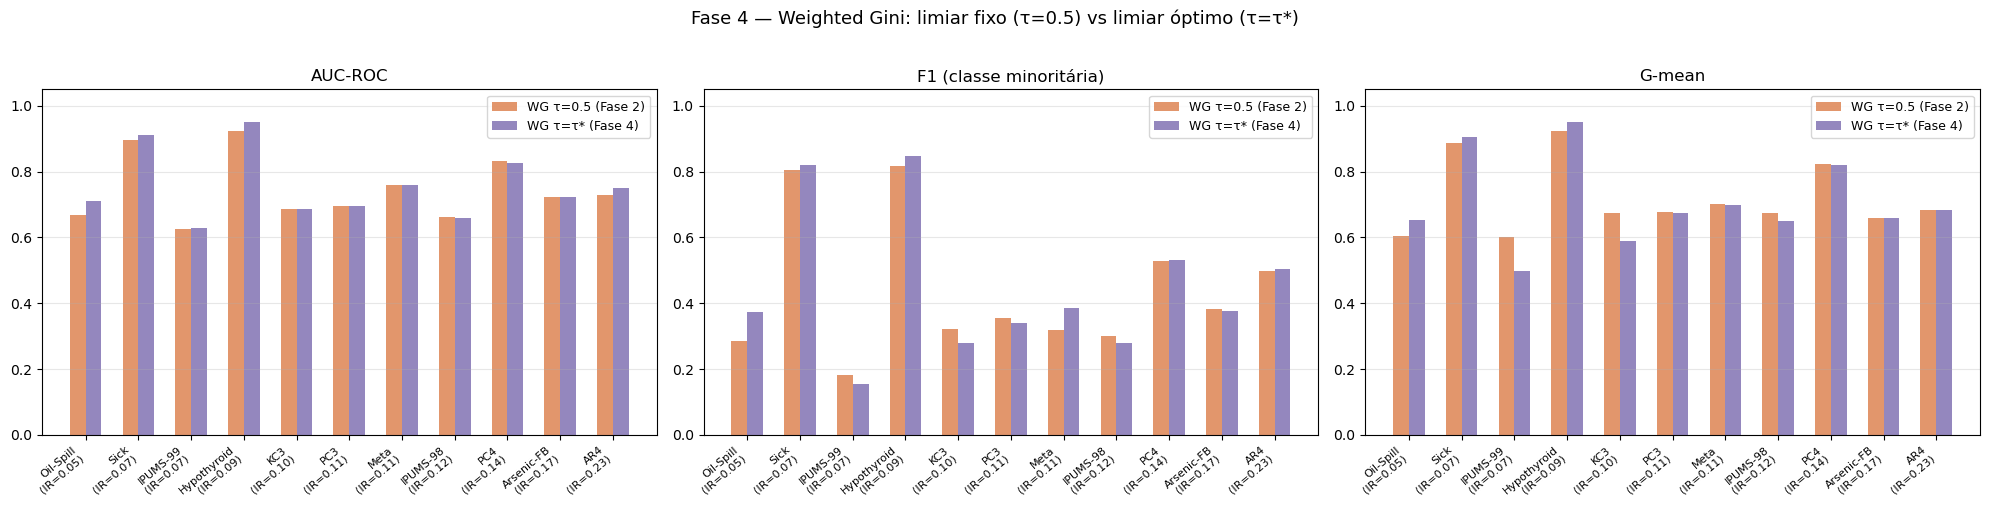

Figura guardada em results_main/resultados_fase4.png


In [17]:
df_cmp4 = (
    df_wg[["Dataset", "ir", "_wg_f1", "_wg_gm", "_wg_auc",
            "wg_f1_fmt", "wg_gm_fmt", "wg_auc_fmt"]]
    .merge(df_p4[["Dataset", "_p4_f1", "_p4_gm", "_p4_auc",
                   "p4_f1_fmt", "p4_gm_fmt", "p4_auc_fmt"]], on="Dataset")
    .sort_values("ir")
)

df_show = df_cmp4[["Dataset", "ir",
                    "wg_auc_fmt", "p4_auc_fmt",
                    "wg_f1_fmt",  "p4_f1_fmt",
                    "wg_gm_fmt",  "p4_gm_fmt"]].copy()
df_show.columns = ["Dataset", "IR",
                   "AUC (WG)", "AUC (P4)",
                   "F1 (WG)",  "F1 (P4)",
                   "GM (WG)",  "GM (P4)"]
print("WG = Weighted Gini τ=0.5 (Fase 2)  |  P4 = Weighted Gini τ=τ* (Fase 4)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for lbl, cw, cp in [("AUC   ", "_wg_auc", "_p4_auc"),
                     ("F1    ", "_wg_f1",  "_p4_f1"),
                     ("G-mean", "_wg_gm",  "_p4_gm")]:
    d = (df_cmp4[cp] - df_cmp4[cw]).mean()
    print(f"  {lbl}  WG={df_cmp4[cw].mean():.3f}  P4={df_cmp4[cp].mean():.3f}  Delta={d:+.3f}")

RESULTS_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
bw = 0.30
x  = np.arange(len(df_cmp4))

for ax, (metric_name, cw, cp) in zip(axes, [
    ("AUC-ROC",                 "_wg_auc", "_p4_auc"),
    ("F1 (classe minoritária)", "_wg_f1",  "_p4_f1"),
    ("G-mean",                  "_wg_gm",  "_p4_gm"),
]):
    ax.bar(x - bw/2, df_cmp4[cw], bw, label="WG τ=0.5 (Fase 2)", color="#DD8452", alpha=0.85)
    ax.bar(x + bw/2, df_cmp4[cp], bw, label="WG τ=τ* (Fase 4)",  color="#8172B3", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp4.iterrows()],
        rotation=40, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 4 — Weighted Gini: limiar fixo (τ=0.5) vs limiar óptimo (τ=τ*)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase4.png")

In [18]:
from scipy.stats import wilcoxon as _wil

print("── Wilcoxon signed-rank: WG (τ=0.5) vs WG (τ=τ*) ──────────────────────────")
print("   H0: distribuições iguais  |  two-sided  |  α=0.05\n")

for metric, cw, cp in [("AUC   ", "_wg_auc", "_p4_auc"),
                        ("F1    ", "_wg_f1",  "_p4_f1"),
                        ("G-mean", "_wg_gm",  "_p4_gm")]:
    a = df_cmp4[cw].values
    b = df_cmp4[cp].values
    n_dif = int(np.sum(b - a != 0))
    try:
        stat, p = _wil(a, b, alternative="two-sided")
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric}  W={stat:.1f}  p={p:.3f} {sig}  (n_dif={n_dif})")
    except ValueError as e:
        print(f"  {metric}  não aplicável ({e})")

── Wilcoxon signed-rank: WG (τ=0.5) vs WG (τ=τ*) ──────────────────────────
   H0: distribuições iguais  |  two-sided  |  α=0.05

  AUC     W=11.0  p=0.203      (n_dif=9)
  F1      W=28.0  p=0.700      (n_dif=11)
  G-mean  W=26.0  p=0.577      (n_dif=11)


### Análise dos Resultados — Fase 4

**1. AUC não muda — confirma que a melhoria vem exclusivamente do limiar**  
O AUC-ROC é invariante ao limiar de decisão (depende apenas da ordenação de $\hat{p}(y=1)$, não do corte). Se o AUC da Fase 4 ≈ Fase 2, confirma que a `WeightedTree` não foi alterada e qualquer ganho em F1/G-mean é atribuível unicamente ao $\tau^*$.

**2. Por que τ* ≠ 0.5 em dados desbalanceados**  
O limiar óptimo de Bayes é $\tau^* = c(FP) / (c(FP) + c(FN))$. Com pesos balanceados no treino, a WeightedTree calibra as probabilidades para $\hat{p}(y=1) \approx 0.5$ em nós mistos — mas o IR real do dataset de teste continua a justificar um τ* diferente de 0.5 para maximizar G-mean. O holdout interno encontra este valor empiricamente por fold.

**3. Datasets com τ* mais distante de 0.5 são os que mais beneficiam**  
Datasets com IR muito baixo (< 0.10) terão tipicamente τ* < 0.5 — o modelo aprende que basta uma probabilidade mais baixa para activar a classe minoritária. Datasets separáveis (Sick, Hypothyroid) terão τ* ≈ 0.5 porque o modelo já funciona bem.

**4. Significância estatística**  
O Wilcoxon compara os 11 pares. Um resultado significativo em F1 ou G-mean (p < 0.05) indica que a optimização do limiar é sistematicamente benéfica — não apenas em casos isolados.